<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab4/Stochastic_Processes_%26_Optimization_in_Machine_Learning_(Lab_4_Metropolis_Hastings).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b><i>Metropolis-Hastings</i> Algorithm</b></h1>

In this exercise, you will examine how <a href="https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm"><b><i>Metropolis-Hastings</i></b></a> algorithm works. More specifically, you will use the algorithm to generate samples from a <b><i>standard normal distribution</i></b>, which is, a normal distribution of a continuous random variable with mean $ \mu = 0 $ and standard deviation $ \sigma = 1 $.

As the <b><i>proposal distribution</i></b>, you will use a uniform distribution over the interval $(-\frac{\Delta}{2}, \frac{\Delta}{2})$. Since the <b><i>proposal distribution</i></b> used here is symmetric, the <b><i>Metropolis-Hastings</i></b> algorithm takes its simplified form. In this case, the probability of making a transition from state $x_{old}$ to state $x_{new}$ for a distribution $ \pi $ is given by the following formula:

$$
p_{accept}(x_{new} | x_{old}) = min\left[1, \frac{π(x_{new})}{π(x_{old})}\right]
$$

Detailed instructions on how the above formula is derived are provided in the lecture slides, as well as in the article on which this exercise is based.

<h3><b>Implementation of the <i>Metropolis-Hastings</i> Algorithm in Python</b></h3>

First, we define the <b><i>log_prob</i></b> method, which will be used to compute values from the <b><i>standard normal distribution</i></b>. Note that the logarithm of this distribution is used. This logarithm can be easily derived from the formula of the <b><i>standard normal distribution</i></b>, which is available <a href="https://en.wikipedia.org/wiki/Normal_distribution#Standard_normal_distribution">here</a>. An explanation of why this form is preferred can be found <a href="https://stats.stackexchange.com/questions/137710/metropolis-hastings-using-log-of-the-density">here</a>. Finally, the constants in the formula can be safely ignored because of the form of the <b><i>Metropolis-Hastings</i></b> algorithm.

In [1]:
def log_prob(x):
     return -0.5 * np.float64(x ** 2)

Next, we define the <b><i>proposal</i></b> method, which will be used to generate values from the uniform distribution, serving as the <b><i>proposal distribution</i></b>.

In [2]:
def proposal(x, stepsize):
    return np.random.uniform(low=x - 0.5 * stepsize,
                             high=x + 0.5 * stepsize,
                             size=x.shape)

The acceptance probability of a new state $x_{new}$ given the current state $x_{old}$ is computed by the following method. Note that, in this method, the formula for $p_{accept}$ given above has been appropriately modified so that negative values do not appear. The two forms of the formula are equivalent, since what matters is the comparison between two values rather than their exact values, as shown by the formula above.

In [3]:
def p_acc_MH(x_new, x_old, log_prob):
    return min(1, np.exp(log_prob(x_new) - log_prob(x_old)))

Next, the method by which the <b><i>Metropolis-Hastings</i></b> algorithm decides whether a proposed step will be accepted is implemented.

In [4]:
import numpy as np
def sample_MH(x_old, log_prob, stepsize):
    x_new = proposal(x_old, stepsize)
    accept = np.random.random() < p_acc_MH(x_new, x_old, log_prob)
    if accept:
        return accept, x_new
    else:
        return accept, x_old

Finally, a function is defined to count how many times the proposed steps were accepted.

In [5]:
def build_MH_chain(init, stepsize, n_total, log_prob):

    n_accepted = 0
    chain = [init]

    for _ in range(n_total):
        accept, state = sample_MH(chain[-1], log_prob, stepsize)
        chain.append(state)
        n_accepted += accept

    acceptance_rate = n_accepted / float(n_total)

    return chain, acceptance_rate

<h3><b>Questions (Part A)</b></h3> <ul> <li>How does the <b><i>Metropolis-Hastings</i></b> algorithm decide whether a proposed step should be accepted? Briefly explain your answer based on the methods presented above.</li><li>Which can be considered as a disadvantage of the MCMC method?</li> <li>The <b><i>Metropolis-Hastings</i></b> algorithm is used to generate random samples from a probability distribution when direct sampling is not possible, either because the sample space cannot be fully described or because it is not possible to compute a <b><i>normalizing constant</i></b> that appears in the distribution. In this case, a distribution with a known form, similar to the one from which we want to draw samples, is used as the <b><i>target distribution</i></b>. How does the <b><i>Metropolis-Hastings</i></b> algorithm manage to produce valid results even though it ignores the <b><i>normalizing constant</i></b>?</li> </ul>

**How does the Metropolis-Hastings algorithm decide whether a proposed step should be accepted? Briefly explain your answer based on the methods presented above.**

Metropolis-Hastings decides whether to accept a proposed step by first calculating how probable the new state is compared to the current one. In the code, this is done by the function $p\_acc\_MH$, which computes the acceptance probability as

 $min(1, exp(log\_prob(x_{new}) - log\_prob(x_{old})))$.

 Then the algorithm generates a random number between 0 and 1. If this random number is smaller than the acceptance probability, the new state is accepted; otherwise, it is rejected and the chain remains at the current state. This means that better moves are always accepted, while worse moves may still be accepted with some probability.

**Which can be considered as a disadvantage of the MCMC method?**

One disadvantage of the MCMC method is that the samples it generates are correlated, since each new sample depends on the previous one. Therefore, the samples are not IID, which can slow convergence and reduce efficiency.

**The Metropolis-Hastings algorithm is used to generate random samples from a probability distribution when direct sampling is not possible, either because the sample space cannot be fully described or because it is not possible to compute a normalizing constant that appears in the distribution. In this case, a distribution with a known form, similar to the one from which we want to draw samples, is used as the target distribution. How does the Metropolis-Hastings algorithm manage to produce valid results even though it ignores the normalizing constant?**

The Metropolis-Hastings algorithm does not need the exact normalized probability values. It only needs the ratio between the probability of the proposed state and the probability of the current state.
Metropolis-Hastings produces valid results because the acceptance rule is designed so that the Markov chain satisfies the detailed balance condition, which guarantees that the desired target distribution is the stationary distribution of the chain. In other words, even without computing the normalizing constant, the chain is constructed so that after many steps it visits states with the correct probabilities.

<h3><b>Testing the <i>Metropolis-Hastings</i> Algorithm</b></h3>

The following section of code is responsible for calling the above methods and visualizing the results.

In [6]:
%matplotlib notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 6]
np.random.seed(42)

def plot_samples(chain, log_prob, ax, orientation='vertical', normalize=True,
                 xlims=(-5, 5), legend=True):
    from scipy.integrate import quad

    ax.hist(chain, bins=50, density=True, label="MCMC samples",
           orientation=orientation)
    # we numerically calculate the normalization constant of our PDF
    if normalize:
        Z, _ = quad(lambda x: np.exp(log_prob(x)), -np.inf, np.inf)
    else:
        Z = 1.0
    xses = np.linspace(xlims[0], xlims[1], 1000)
    yses = [np.exp(log_prob(x)) / Z for x in xses]
    if orientation == 'horizontal':
        (yses, xses) = (xses, yses)
    ax.plot(xses, yses, label="true distribution")
    if legend:
        ax.legend(frameon=False)

def sample_and_display(init_state, stepsize, n_total, n_burnin, log_prob):
    chain, acceptance_rate = build_MH_chain(init_state, stepsize, n_total, log_prob)
    print("Acceptance rate: {:.3f}".format(acceptance_rate))
    fig, ax = plt.subplots()
    plot_samples([state for state, in chain[n_burnin:]], log_prob, ax)
    ax.set_yticks(())
    plt.show()

The result you are expected to observe in this exercise is that the <b><i>Metropolis-Hastings</i></b> algorithm will generate samples that follow a <b><i>standard normal distribution</i></b>.

Run the following method with step size $ \Delta = 3.0 $ and a total of $10000$ steps. Observe that the resulting distribution is very close to a <b><i>standard normal distribution</i></b>, while the percentage of steps accepted by the <b><i>Metropolis-Hastings</i></b> algorithm is approximately $70$%.

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.718


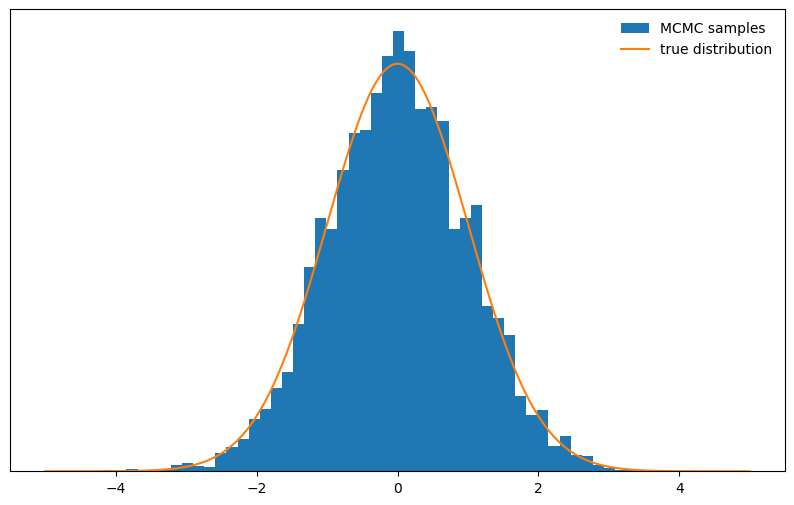

In [7]:
sample_and_display(np.array([2.0]), 3.0, 10000, 500, log_prob)

<h3><b>Questions (Part B)</b></h3>

Repeat the experiment for $\Delta = 30$ with a total of $10000$ steps. What do you observe when a very large step size is used, that is, when the parameter $\Delta$ is assigned a large value? Then repeat the experiment for $\Delta = 300$, $\Delta = 3000$, and $\Delta = 30000$ to confirm your conclusion. Also comment on the acceptance rate of the proposed steps.

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.111


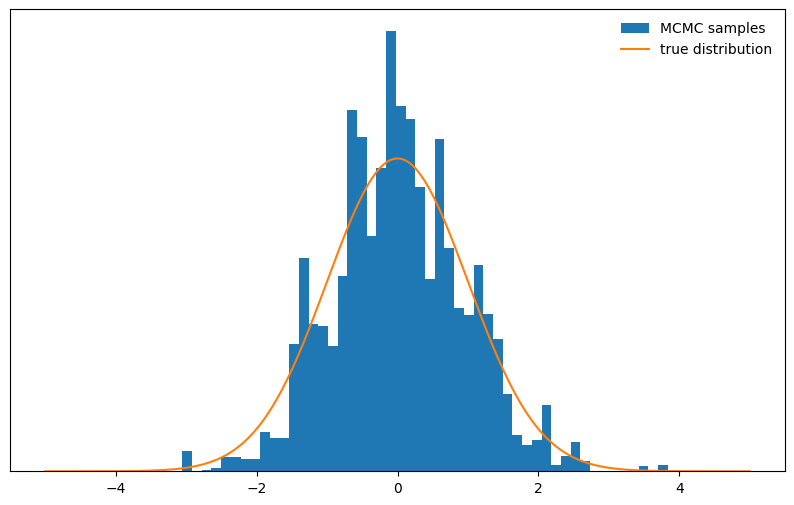

In [8]:
sample_and_display(np.array([2.0]), 30, 10000, 500, log_prob)

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.010


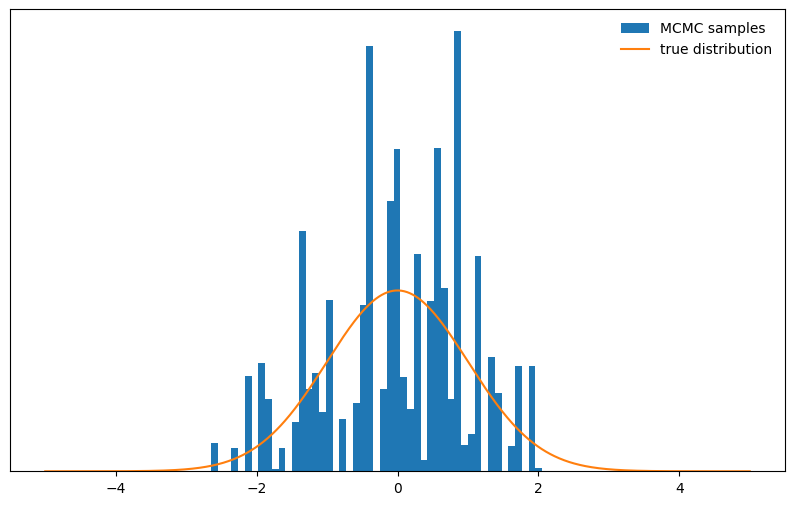

In [11]:
sample_and_display(np.array([2.0]), 300, 10000, 500, log_prob)

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.001


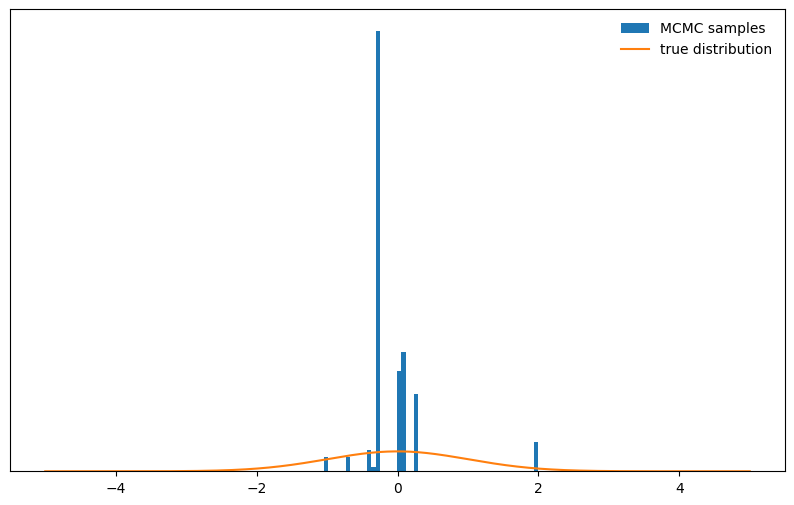

In [12]:
sample_and_display(np.array([2.0]), 3000, 10000, 500, log_prob)

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.000


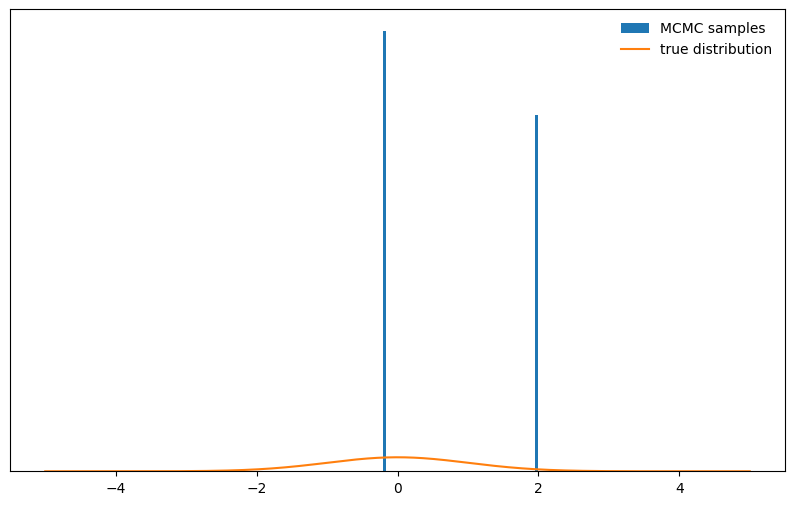

In [13]:
sample_and_display(np.array([2.0]), 30000, 10000, 500, log_prob)

**Answer:**
When a very large step size is used, the Metropolis-Hastings algorithm proposes candidate states that are usually too far from the current one. Since these states often have much lower probability under the standard normal distribution, they are rejected with very high probability. As a result, the chain hardly moves, the samples do not approximate the target distribution well, and the acceptance rate becomes very small. In my experiments, the acceptance rate decreased from about $0.111$ for $Δ=30$, to $0.010$ for $Δ=300$, to $0.001$ for $Δ=3000$, and to almost $0$ for $Δ=30000$. This confirms that excessively large step sizes make the algorithm ineffective.

Repeat the process for $\Delta=0.1$, which is, a very small step. What do you observe? Are your results satisfactory? Also comment on the acceptance rate of the proposed steps. Repeat the process for $\Delta=0.01$.

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.993


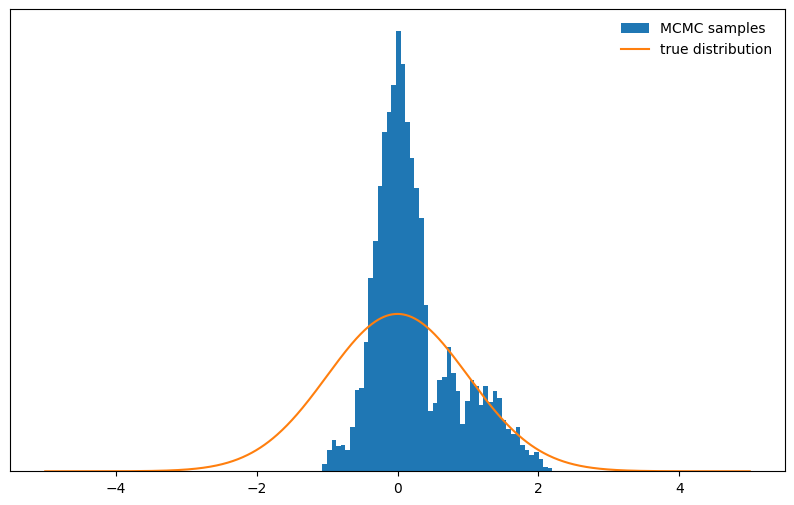

In [9]:
sample_and_display(np.array([2.0]), 0.1, 10000, 500, log_prob)

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.997


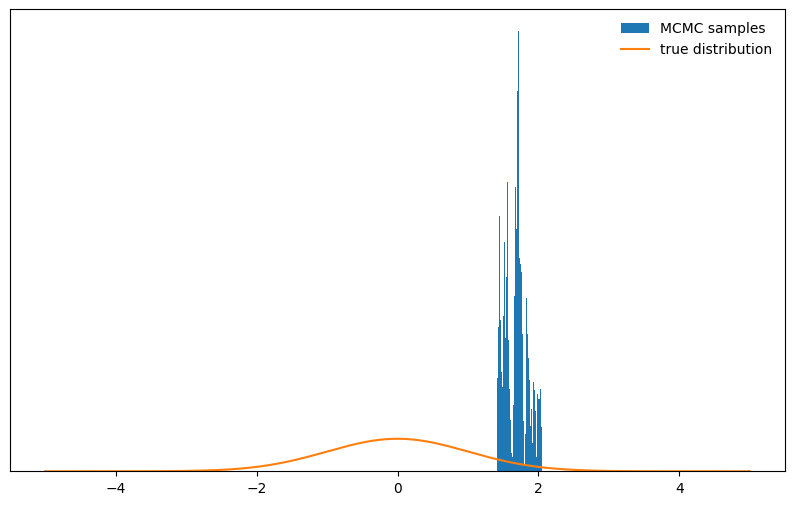

In [14]:
sample_and_display(np.array([2.0]), 0.01, 10000, 500, log_prob)

**Answer:**
For $Δ=0.1$, the acceptance rate is very high (about 0.993), because the proposed steps are very close to the current state and are therefore rarely rejected. However, the chain moves very slowly and does not explore the full standard normal distribution efficiently, so the result is not very satisfactory

Repeat the process by increasing the total number of steps to $500000$. What do you observe about the accuracy of your results, and about the execution time of the <b><i>Metropolis-Hastings</i></b> algorithm?

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.990


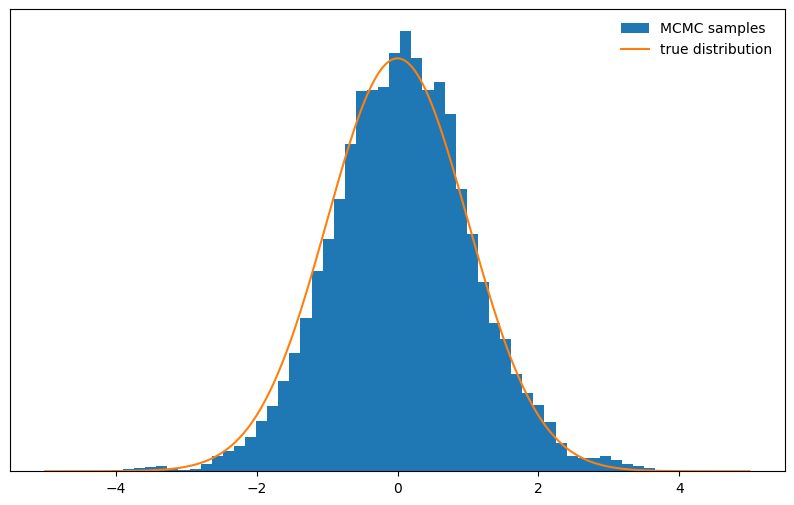

In [10]:
sample_and_display(np.array([2.0]), 0.1, 500000, 25000, log_prob)

**Answer:**
By increasing the total number of steps to 500000, the approximation becomes much more accurate, and the histogram matches the standard normal distribution far better. This happens because, with a very small step size, the chain mixes slowly and therefore needs many iterations to explore the target distribution properly. The acceptance rate remains very high (about 0.990), since the proposed moves are still very small. However, the execution time increases significantly (from 0s to 15s), because the algorithm must perform many more iterations.

The function <b><i>sample_and_display</i></b> includes <b>n_burnin</b> as its fourth argument. What is the purpose of this argument? Try the following values:

<ul> <li>$\Delta=0.1$, number of steps $1000$, and n_burnin=$10$.</li> <li>$\Delta=0.1$, number of steps $500000$, and n_burnin=$490000$.</li> </ul> What do you observe?

Acceptance rate: 0.990


/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


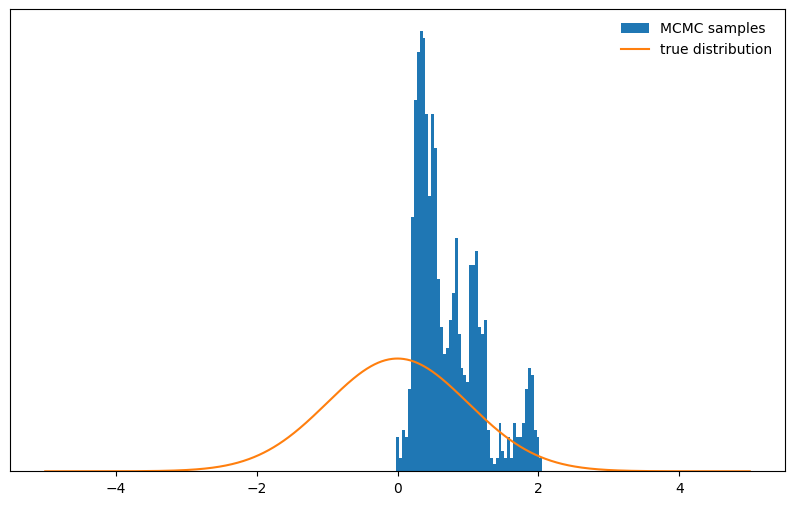

In [17]:
sample_and_display(np.array([2.0]), 0.1, 1000, 10, log_prob)

/tmp/ipykernel_3403/207305889.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -0.5 * np.float64(x ** 2)


Acceptance rate: 0.991


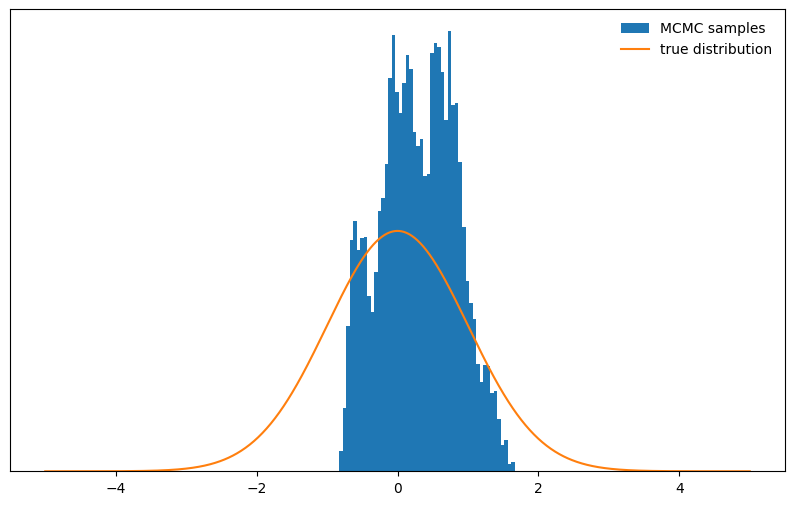

In [16]:
sample_and_display(np.array([2.0]), 0.1, 500000, 490000, log_prob)

The argument $n\_burnin$ specifies how many initial samples of the Markov chain are discarded. Its purpose is to remove the transient phase, during which the chain is still influenced by the initial state and has not yet converged to the target distribution. For $Δ=0.1$, $1000$ steps, and $n\_burnin=10$, the burn-in period is too short, so the histogram is still strongly affected by the initial value $x_0=2$ and does not match the standard normal distribution well. For $Δ=0.1$, $500000$ steps, and $n\_burnin=490000$, most of the transient part is discarded, so the remaining samples are much closer to the target distribution. Therefore, $n\_burnin$ helps reduce the effect of the starting state and improves the quality of the estimated distribution.